# Genetic Algorithm (GA)

- Autor: <span style="color:red">Rodrigo S. Cortez-Madrigal</span>
- web: [https://roicort.github.io](https://roicort.github.io)
- github: [https://github.com/roicort/MetaZoo](https://github.com/roicort/MetaZoo)
- docs: [https://roicort.github.io/MetaZoo/](https://roicort.github.io/MetaZoo/)

### Objetivo

Implementar un Algoritmo Genético (AG) que incorpore elitismo y compare el desempeño de distintos operadores de selección: Ruleta, Muestreo Estocástico Universal (SUS) y Torneo. El propósito es analizar y contrastar sus efectos sobre convergencia, calidad de solución y estabilidad.

### Requisitos de implementación

1) Elitismo (obligatorio)
    - Integre un esquema de elitismo y especifique cuál utiliza:
        - Mejor individuo (p. ej., 1 élite).
        - Porcentaje de mejores (p. ej., 5–10% de la población).
        - Total (todos los individuos élite pasan sin alteración)
    
Para esta implementación se utiliza un porcentaje de mejores (configurable por el usuario). [Ver Implementación](https://roicort.github.io/MetaZoo/ga/#evolve)

2) Operadores de selección (obligatorios)
    - Implemente y ejecute el AG con cada uno de los siguientes:
        - Ruleta. [Ver Implementación](https://roicort.github.io/MetaZoo/evolutionary/operators/#metazoo.bio.evolutionary.operators.selection.roulette)
        - SUS (Stochastic Universal Sampling). [Ver Implementación](https://roicort.github.io/MetaZoo/evolutionary/operators/#metazoo.bio.evolutionary.operators.selection.stochastic_universal_sampling)
        - Torneo: (indique el tipo de torneo utilizado) [Ver Implementación](https://roicort.github.io/MetaZoo/evolutionary/operators/#metazoo.bio.evolutionary.operators.selection.tournament)
            - Se implementó un tamaño del torneo (k) configurable por el usuario.
            - Con o sin reemplazo, según se especifique.
            - Determinístico (el mejor siempre gana) o probabilístico (el mejor gana con cierta probabilidad).

3) Línea base (sugerida)
Incluya Selección Aleatoria (uniforme) como testigo para ilustrar presión de selección baja y sus implicaciones en convergencia. 
Implementada como un operador de selección [Ver Implementación](https://roicort.github.io/MetaZoo/evolutionary/operators/#metazoo.bio.evolutionary.operators.selection.uniform)

### Implementación y Experimentos

In [1]:
from metazoo.bio.evolutionary import GeneticAlgorithm
from metazoo.bio.evolutionary.operators import selection, mutation, crossover
from metazoo.gym.mono import Function

import plotly.io as pio
#pio.renderers.default = "jupyterlab"
pio.renderers.default = "png"

import pandas as pd
from rich.progress import track
import numpy as np
import plotly.express as px

Las funciones de rastringin, ackley y sphere nos sirve en este caso para comparar los operadores de selección y el elitismo dado que sus minimos se encuentran en el origen (0,0) y son funciones bien conocidas en el ámbito de la optimización.

In [2]:
targets = ['Rastrigin',
'Ackley',
'Sphere'
]

In [3]:
from metazoo.bio.utils import encoding

#### Control de variables

Ejecutamos para cada entorno de prueba los tres operadores de selección con y sin elitismo.
Mantenemos constantes (para cada entorno de prueba) la población, número de generaciones, cruza, mutación
y otros parámetros que correspondan, para aislar el efecto de la
selección y del elitismo.

                crossover_function=crossover.onepoint,
                mutation_function=mutation.flip_bit,
                population_size=100,
                mutation_rate=0.01,
                crossover_rate=0.7,
                precision=3,


In [4]:
from functools import partial

# Torneo de tamaño 5, tipo proporcional, con reemplazo
tournament = partial(selection.tournament, K=5, type='proportional', replace=True)

selection_operators = [
    selection.uniform,
    selection.roulette,
    selection.stochastic_universal_sampling,
    selection.rank,
    tournament
]

results = []

np.random.seed(42)

for function in track(targets, description="Processing functions..."):
    fitness_function = Function(function, reverse=False)
    encoder = encoding.Binary(precision=3, bounds=fitness_function.bounds)
    for elitism in [None, 0.1, 0.3, 1.0]:
        for selection_ in [selection.uniform, selection.roulette, selection.stochastic_universal_sampling, selection.rank, selection.tournament]:
            aux_results = []
            aux_best_individual = []
            for _ in range(10):  # 10 runs per configuration
                ga = GeneticAlgorithm(
                    fitness_function=fitness_function,
                    crossover_function=crossover.onepoint,
                    mutation_function=mutation.flip_bit,
                    selection_function=selection_,
                    population_size=100,
                    mutation_rate=0.01,
                    crossover_rate=0.7,
                    encoder=encoder,
                    elitism=elitism,
                    minimize=True
                )
                ga.run(generations=100, verbose=False)
                aux_results.append(ga.best_fitness)
                aux_best_individual.append(ga.best_individual)
            mean_best_fitness = sum(aux_results) / len(aux_results)
            best_individual = np.min(np.array(aux_best_individual), axis=0)
            result = {
                "func": function,
                "elitism": elitism,
                "selection": selection_.__name__,
                "best_fitness_mean": mean_best_fitness,
                "best_individual": best_individual
            }
            results.append(result)

Output()

### Resultados

Juntemos todos los resultados en una tabla para facilitar la comparación.

In [5]:
df = pd.DataFrame(results)
df['best_fitness_mean'] = df['best_fitness_mean'].round(5)
df['best_individual'] = df['best_individual'].apply(lambda x: str([round(i, 5) for i in x]) if isinstance(x, list) else x)
df['elitism'] = df['elitism'].fillna(0).astype(str)

In [6]:
df

,func,elitism,selection,best_fitness_mean,best_individual
0,Rastrigin,0.0,uniform,28.02633,"[-3.8524226332173592, -1.1241311115180372]"
1,Rastrigin,0.0,roulette,1.67473,"[-2.001684673136788, -1.9841836049563573]"
2,Rastrigin,0.0,stochastic_universal_sampling,1.18913,"[-1.0009985961057195, -1.0003735579564186]"
3,Rastrigin,0.0,rank,0.40321,"[-0.0034377098211564316, -0.005312824269059213]"
4,Rastrigin,0.0,tournament,0.67447,"[-0.9897479094182993, -1.0403759995116895]"
5,Rastrigin,0.1,uniform,0.23599,"[-0.02531404504669421, -1.0003735579564186]"
6,Rastrigin,0.1,roulette,0.44115,"[-0.9922480620155039, -0.00031251907465090767]"
7,Rastrigin,0.1,stochastic_universal_sampling,0.33942,"[-0.9953732527620094, -0.9953732527620094]"
8,Rastrigin,0.1,rank,0.46986,"[-0.9953732527620094, -0.9947482146127085]"
9,Rastrigin,0.1,tournament,0.67228,"[-0.00031251907465090767, -0.9947482146127085]"


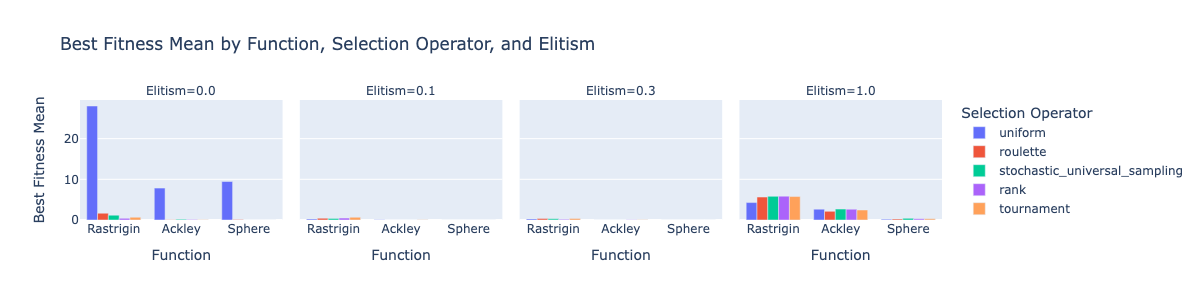

In [7]:
# Grafiquemos 
fig = px.bar(df, x='func', y='best_fitness_mean', color='selection', barmode='group',
             facet_col='elitism', title='Best Fitness Mean by Function, Selection Operator, and Elitism',
             labels={'best_fitness_mean': 'Best Fitness Mean', 'func': 'Function', 'selection': 'Selection Operator', 'elitism': 'Elitism'})
fig.update_layout(height=300, width=1200)
fig.show()

Algunas observaciones interesantes:
- La selección uniforme (aleatoria) tiende a tener un desempeño significativamente peor en comparación con los otros métodos de selección.
- El elitismo mejora consistentemente el desempeño de todos los métodos de selección, pero su impacto es mayor en la selección por torneo y ruleta.
- El elitismo total es la peor estrategia, probablemente porque reduce la diversidad de la población. Mientras que nada de elitismo es mejor que elitismo total, un elitismo moderado (10-30%) parece ofrecer un buen equilibrio entre preservar los mejores individuos y mantener la diversidad genética.

### Exploremos las configuraciones de Selección por Torneo

In [8]:
# Experimento adicional: variar K, reemplazo y tipo de torneo

tournament_results = []

np.random.seed(42)

Ks = [2, 3, 5, 10]
replacements = [True, False]
tournament_types = ['standard','proportional']  
elitism_values = [None, 0.1, 0.3, 1.0]

fitness_fn = Function('Ackley', reverse=False)

for K in track(Ks):
    for replace in replacements:
        for t_type in tournament_types:
            tournament_operator = partial(selection.tournament, K=K, type=t_type, replace=replace)
            for elitism in elitism_values:
                run_best_fitness = []
                run_best_individuals = []
                for _ in range(10):
                    ga = GeneticAlgorithm(
                        fitness_function=fitness_fn,
                        crossover_function=crossover.onepoint,
                        mutation_function=mutation.flip_bit,
                        selection_function=tournament_operator,
                        population_size=100,
                        mutation_rate=0.01,
                        crossover_rate=0.7,
                        encoder=encoder,
                        elitism=elitism,
                        minimize=True
                    )
                    ga.run(generations=100, verbose=False)
                    run_best_fitness.append(ga.best_fitness)
                    run_best_individuals.append(ga.best_individual)
                mean_fit = float(np.mean(run_best_fitness))
                idx_min = int(np.argmin(run_best_fitness))
                best_individual = run_best_individuals[idx_min]
                tournament_results.append({
                    "K": K,
                    "replace": replace,
                    "type": t_type,
                    "elitism": elitism,
                    "best_fitness_mean": mean_fit,
                    "best_individual": best_individual
                })


Output()

In [9]:
tournament_df = pd.DataFrame(tournament_results)
tournament_df['elitism'] = tournament_df['elitism'].fillna(0).astype(str)
tournament_df['K'] = tournament_df['K'].astype(str)
tournament_df['best_fitness_mean'] = tournament_df['best_fitness_mean'].round(6)
tournament_df['best_individual'] = tournament_df['best_individual'].apply(
lambda x: str([round(float(v), 6) for v in x])
)

tournament_df = tournament_df.sort_values(by=["best_fitness_mean"]).reset_index(drop=True)
tournament_df

,K,replace,type,elitism,best_fitness_mean,best_individual
0,10,True,proportional,0.1,0.006836,"[0.000313, 0.000313]"
1,3,True,proportional,0.3,0.011534,"[0.000313, 0.000313]"
2,10,False,proportional,0.1,0.013504,"[-0.000313, 0.000313]"
3,5,True,proportional,0.1,0.017359,"[-0.000313, -0.000313]"
4,2,False,proportional,0.3,0.018458,"[0.000313, -0.000313]"
...,...,...,...,...,...,...
59,3,True,proportional,1.0,2.952478,"[0.1972, 0.20095]"
60,2,True,standard,1.0,2.956673,"[0.027814, 0.158447]"
61,3,True,standard,1.0,3.017606,"[-0.314082, 0.059066]"
62,5,True,standard,1.0,3.053137,"[-0.04219, 0.321582]"


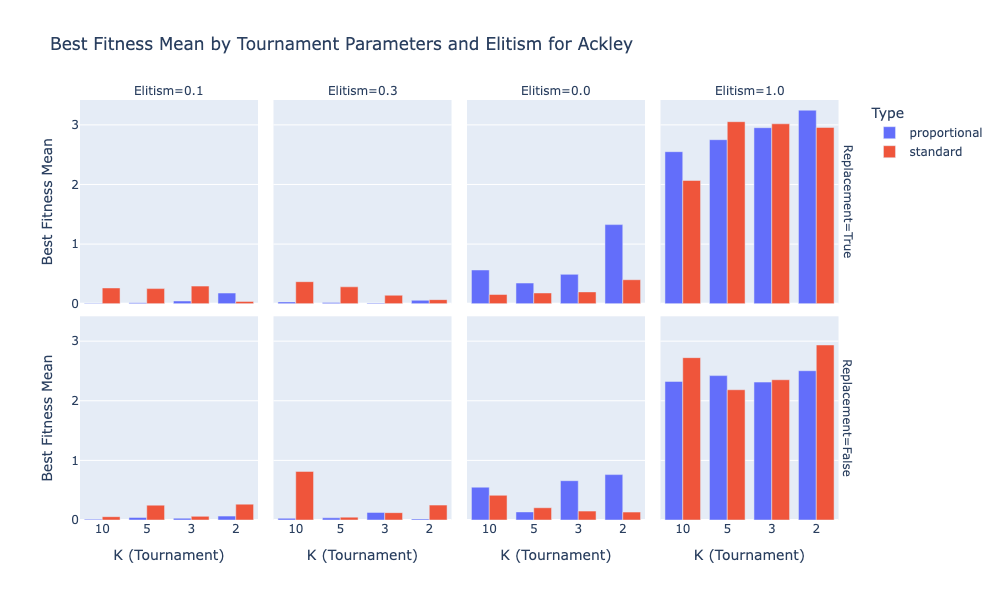

In [10]:
# Grafiquemos
fig2 = px.bar(tournament_df, x='K', y='best_fitness_mean', color='type', barmode='group',
             facet_col='elitism', facet_row='replace',
             title='Best Fitness Mean by Tournament Parameters and Elitism for Ackley',
             labels={'best_fitness_mean': 'Best Fitness Mean', 'K': 'K (Tournament)', 'type': 'Type', 'elitism': 'Elitism', 'replace': 'Replacement'})
fig2.update_layout(height=600, width=1000)
fig2.show()

- Igual aquí podemos observar que el tamaño del torneo (K) tiene un impacto significativo en el desempeño cuando no se utiliza elitismo y sobre todo cuando el tipo de torneo es proporcional. 
- Seguimos observando que el elitismo entre el 10-30% ofrece un buen desempeño.
- Cuando no hay elitismo, el torneo proporcional tiene un desempeño menor. Esto podría ser debido a que el torneo proporcional introduce más aleatoriedad en la selección, lo que puede ser perjudicial cuando no se preservan los mejores individuos.
- Usar remplazo parece tener un impacto pequeño en el desempeño, pero mejor que no usarlo.

## Mejores parámetros y Análisis

De acuerdo con los resultados agrupados y ordenados por best_fitness_mean, la mejor combinación corresponde a los operadores de selección como torneo o rank junto con un elitismo de entre 0.1 y 0.3.

Esto tiene sentido gracias a que los operadores como torneo y rank ejercen mayor presión en la selección de la población, favoreciendo la supervivencia de los mejores individuos (como en la naturaleza). Esto ayuda a mantener la calidad de la población (con los mejores individuos) a lo largo de las generaciones.

Por otro lado, el elitismo entre 0.1 y 0.3 asegura que los mejores individuos no se pierdan, lo que ayuda a preservar soluciones de alta calidad a lo largo de las generaciones. Por otro lado, si el elitismo es muy alto (1.0) se pierde diversidad y la población se estanca rápidamente, lo que se traduce en perder capacidad de exploración.


# Criterios

| **Criterio**                                                           | **W** | **Esperado**                                                                                                                                                                                                                                        | **Done**                                                          |
|------------------------------------------------------------------------|-------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------|
| **1. Implementación de operadores de selección (Ruleta, SUS, Torneo)** | 20    | Implementa los 3 operadores correctamente; documenta precisión de cada método; para Torneo especifica tipo, k, con/sin reemplazo y resolución de empates; Ruleta maneja aptitudes 0/negativas (normalización/shift) y SUS usa puntos equidistantes. | Torneo seleccionable, con y sin remplazo y resolución de empates. |
| **2. Elitismo (tipo y parámetros)**                                    | 20    | Integra elitismo y declara explícitamente el tipo (mejor individuo / % mejores / total), el porcentaje/número, si saltan cruza/mutación, y el mecanismo de inserción en la siguiente generación; justifica su elección.                             | Elitismo con n% mejores como input.                               |
| **3. Diseño experimental (control de variables + baseline)**           | 15    | Mantiene constantes población, generaciones, representación, fitness, cruza, mutación y tasas entre operadores; incluye baseline de Selección Aleatoria; detalla configuración.                                                                     | En este reporte                                                   |
| **5. Visualizaciones (consistencia y legibilidad)**                    | 15    | Gráficas comparables, líneas de mejor y media, leyendas claras, títulos que incluyen operador y tipo de elitismo; figuras legibles.                                                                                                                 | En este reporte                                                   |
| **6. Resultados y discusión**                                          | 10    | Identifica la mejor combinación (operador + elitismo) y razona causas (presión de selección, diversidad, estancamiento); discute trade-offs (velocidad vs. calidad), efectos de elitismo y del torneo; reconoce limitaciones.                       | En este reporte                                                   |
| **7. Reproducibilidad (código)**                                       | 10    | Código limpio y modular; requisitos, comandos de ejecución, parámetros, es posible replicar todas las condiciones; estructura de carpetas clara.                                                                                                    | En repositorio                                                    |
| **8. Informe (PDF) claridad y estructura**                             | 10    | Breve y claro: problema, AG (representación/fitness/cruza/mutación), operadores y tipo de torneo, elitismo (tipo y parámetros), setup experimental, resultados, gráficas y tabla resumen, conclusiones; redacción formal.                           | En este reporte                                                   |
